# 00 · Dataset acquisition and preprocessing

**Owner:** Ishaan Karmokar  
ICT-4442 mini project: ECG arrhythmia classification on the MIT-BIH Arrhythmia Database.

This notebook downloads the records, runs the shared cleaning and segmentation pipeline (`src/build_dataset.py`) and documents the resulting train / validation / test split that all four models use.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

## 1. Download the 44 non-paced records from PhysioNet
Records 102, 104, 107 and 217 contain paced beats and are excluded, following the AAMI EC57 recommendation and de Chazal et al. (2004).

In [2]:
from config import DS1, DS2, DS1_TRAIN, DS1_VAL
print(len(DS1), "DS1 records:", DS1)
print(len(DS2), "DS2 records:", DS2)
print("validation records held out of DS1:", DS1_VAL)
!cd .. && python src/download_data.py

22 DS1 records: ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']
22 DS2 records: ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']
validation records held out of DS1: ['108', '114', '116', '124', '207', '223']
zsh:1: command not found: python


## 2. Clean, segment and label
1. MLII lead read with `wfdb`  
2. baseline wander removed with cascaded 200 ms / 600 ms median filters  
3. 35 Hz zero-phase Butterworth low-pass  
4. annotation symbols mapped to the AAMI classes N, S, V, F, Q  
5. one-second window (360 samples) centred on each annotated R peak, z-scored per beat  
6. four RR-interval features per beat

In [3]:
!cd .. && python src/build_dataset.py | tail -12

zsh:1: command not found: python


In [4]:
d = np.load(os.path.join(ROOT, "data", "processed", "beats.npz"))
X, F, y, split, rec = d["X"], d["F"], d["y"], d["split"], d["rec"]
from config import CLASSES
import pandas as pd
tab = pd.DataFrame({sp: [int(((split == sp) & (y == i)).sum()) for i in range(5)]
                    for sp in ["train", "val", "test"]}, index=CLASSES).T
tab["total"] = tab.sum(1)
tab

/var/folders/fj/ls7k99g10dq4r0xpqcx79kxw0000gn/T/ipykernel_63222/1602992871.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tab["total"] = tab.sum(1)


,N,S,V,F,Q,total
train,34853,716,2889,389,8,38855
val,10979,227,899,25,0,12130
test,44228,1836,3220,388,7,49679


## 3. What the cleaning does

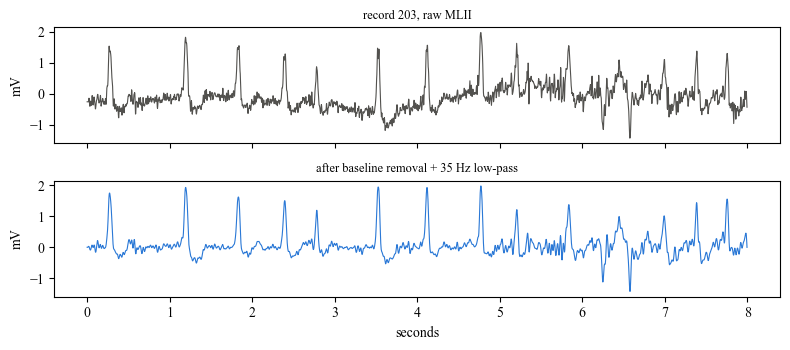

In [5]:
import wfdb
from build_dataset import clean, RAW
sig = wfdb.rdrecord(os.path.join(RAW, "203"), sampfrom=0, sampto=360*8)
raw = sig.p_signal[:, 0]
t = np.arange(len(raw)) / 360
fig, ax = plt.subplots(2, 1, figsize=(8, 3.6), sharex=True)
ax[0].plot(t, raw, lw=.8, color="#52514e"); ax[0].set_title("record 203, raw MLII", fontsize=9)
ax[1].plot(t, clean(raw), lw=.8, color="#2a78d6"); ax[1].set_title("after baseline removal + 35 Hz low-pass", fontsize=9)
ax[1].set_xlabel("seconds")
for a in ax: a.set_ylabel("mV")
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "preprocessing.png"), dpi=300); plt.show()

## 4. One example beat per class (training split)

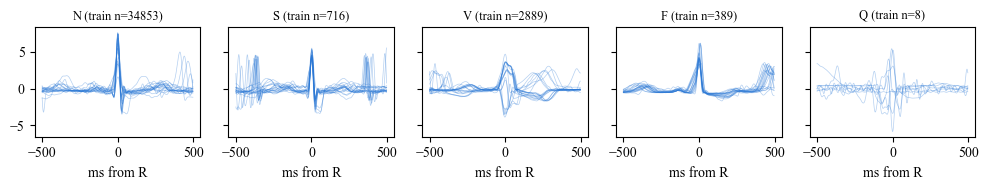

In [6]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
ts = (np.arange(360) - 180) / 360 * 1000
for i, c in enumerate(CLASSES):
    idx = np.flatnonzero((y == i) & (split == "train"))
    for j in rng.choice(idx, min(20, len(idx)), replace=False):
        ax[i].plot(ts, X[j], lw=.5, alpha=.35, color="#2a78d6")
    ax[i].set_title(f"{c} (train n={len(idx)})", fontsize=9); ax[i].set_xlabel("ms from R")
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "example_beats.png"), dpi=300); plt.show()

## 5. RR features separate S from N; shape alone does not
An S beat looks almost like an N beat but arrives early, so its pre-RR / local-RR ratio drops below 1.

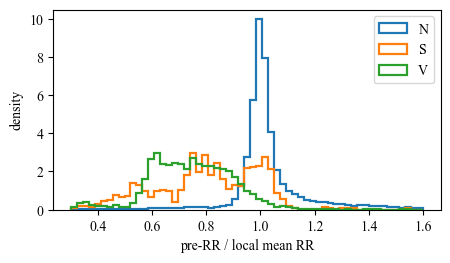

In [7]:
fig, ax = plt.subplots(figsize=(5, 2.6))
for i, c in enumerate(["N", "S", "V"]):
    m = (y == i) & (split == "train")
    ax.hist(F[m, 3], bins=np.linspace(0.3, 1.6, 60), density=True, histtype="step", lw=1.6, label=c)
ax.set_xlabel("pre-RR / local mean RR"); ax.set_ylabel("density"); ax.legend()
plt.show()

## 6. Caveats carried into every result
* Only 15 usable Q beats exist after excluding paced records (8 train, 0 validation, 7 test), so Q-class scores are reported but not interpreted.
* F beats are concentrated in a few records (record 208 holds most DS1 F beats), so validation has only 25 F beats.
* Records 201 and 202 come from the same patient but fall in DS1 and DS2 respectively in the standard de Chazal split; we keep the standard split for comparability with the literature and note this.